## Generating supplementary figure showing the results from fitting with adaptation (w_ad !=0)

#### Ilaria Carannante
mailto: ilariac@kth.se
###### NeuroPSI, ICN, Saclay, France

This notebook does no fitting. It reloads the simulated transfer-function data and the
retained fits produced by *TF_fitting_RS_wad.ipynb*, and assembles the manuscript supplementary figure.

Run the fitting notebooks first: this notebook reads
`results/10_best_params_TF_RS_wad.json`, which they write.

## Imports

In [1]:
#%matplotlib widget
import matplotlib.pyplot as plt

In [2]:
import sys
import os

# Adding the project folder to sys.path
cwd = os.getcwd()
parent_dir = os.path.abspath(os.path.join(cwd, '..', '..',))
sys.path.append(parent_dir)
# We do this so that we can directly import files in the utils folder

In [3]:
import json
import numpy as np
import pandas as pd

from utils.Plots_helper import *
from ntmf.transfer_function import *
from ntmf.config import get_params_model_SI, get_network_config, adding_K_params

## Configuration

`simulation_folder` and `data_file` are the only entries that have to match what the
data-extraction scripts actually wrote. The loader raises if a path is missing and lists
what is present in the simulations directory, so a typo is reported rather than silently
producing an empty panel.

In [4]:
MODELS = {
    'RS': dict(
        simulation_folder = '../data_extraction/simulations/TF_RS_w_v1',
        data_file         = 'testing_TF_data_RS_w.dat',
    )
}

# Number of retained fits per cell type, as written by the fitting notebooks.
N_BEST = 10

data_folder            = '../../neuron_models/AdEx'
network_config_folder  = '../../config/'
network_file_name      = 'network_config_file_v0.json'
results_path           = 'results'

In [5]:
fig_path = os.path.join('figures')
isExist = os.path.exists(fig_path)
if not isExist:
   os.makedirs(fig_path)
   print('The directory "figures" is created.')

def save_figs(fig_path, name, figs):
    pdf_file_path = os.path.join(fig_path, name + '-figs.pdf')
    with PdfPages(pdf_file_path) as ofile:
        for fig in figs:
            ofile.savefig(fig)

In [6]:
network_config = get_network_config(
    json_file_name = os.path.join(network_config_folder, network_file_name))

## Loading the data and the retained fits

For each cell type the loader returns the simulated table with one column per retained
fit, `fit_rate_alpha_0` ... `fit_rate_alpha_9`, ordered by increasing mean error.
`fit_rate` is an alias of `fit_rate_alpha_0`, i.e. the best fit, so that the dataframes
are accepted unchanged by the plotting functions used in the fitting notebooks.

Every fitted column is evaluated at the stationary adaptation current `w_ad`, read from
the `avg_w` column of the data, i.e. the current under which the polynomial was trained.
Evaluating an adaptation-trained fit at `w_ad = 0` biases the predicted rate upward where
`w_ad` is largest and disagrees with the stored `mean_error`; the loader raises if
`avg_w` is absent rather than falling back to zero.

`residual_pct` is the residual as a percentage of that cell type's largest simulated
rate. Cell types covering different output ranges are not comparable in Hz, so this is
the column plotted in the third column of the main figure and the one summarised as
nRMSE.

In [7]:
def load_model(neuron_model, cfg, n_best=N_BEST):
    """Reload the simulated transfer function and the retained fits of one cell type.

    The retained fits were trained on the adaptive data with the stationary
    adaptation current w_ad != 0, saved as the ``avg_w`` column of the .dat file
    (SI Amps). Each fitted rate is re-evaluated with that same w_ad: passing the
    polynomial through TF_template at w_ad = 0 evaluates an adaptation-trained fit
    at zero adaptation, which biases the predicted rate upward where w_ad is
    largest (high excitation, low inhibition) and breaks agreement with the stored
    mean_error. w_ad is a property of the data and is shared by all retained fits.

    Returns
    -------
    dict with keys 'df', 'params_SI', 'alpha', 'mean_error', 'fit_cols',
    'exc_vals', 'inh_vals', 'max_rate', 'entries', 'w_ad'.
    """
    dat_file = os.path.join(cfg['simulation_folder'], cfg['data_file'])
    if not os.path.exists(dat_file):
        sim_root = os.path.dirname(cfg['simulation_folder'])
        present = sorted(os.listdir(sim_root)) if os.path.isdir(sim_root) else []
        raise FileNotFoundError(
            f"{neuron_model}: '{dat_file}' not found.\n"
            f"Folders present in '{sim_root}': {present}")

    best_file = os.path.join(results_path, f'10_best_params_TF_{neuron_model}_wad.json')
    if not os.path.exists(best_file):
        raise FileNotFoundError(
            f"{neuron_model}: '{best_file}' not found. Run TF_fitting_{neuron_model}_wad.ipynb "
            "and its 'Saving the 10 best fits' cell first.")

    params_SI = get_params_model_SI(
        neuron_model = neuron_model,
        json_file_name = os.path.join(data_folder, neuron_model + '.json'))
    params_SI = adding_K_params(neuron_params = params_SI,
                                network_config = network_config)

    df = pd.read_csv(dat_file, sep=r'\s+', header=0)

    # Stationary adaptation current the fits were trained under. Refuse rather
    # than silently fall back to w_ad = 0, which would reproduce the non-adaptive
    # prediction under an adaptation label.
    if 'avg_w' not in df.columns:
        raise KeyError(
            f"{neuron_model}: column 'avg_w' not found in '{dat_file}'. "
            f"Columns present: {list(df.columns)}. This notebook re-evaluates the "
            "adaptation fits and needs the adaptation current saved by "
            "TF_data_extraction_RS.py. Re-extract the data, or point 'data_file' at "
            "the _w dataset.")
    w_ad = df['avg_w'].to_numpy()

    with open(best_file, 'r') as f:
        entries = json.load(f)
    entries = sorted(entries, key=lambda e: e['mean_error'])[:n_best]
    if len(entries) < n_best:
        print(f"[{neuron_model}] warning: only {len(entries)} retained fits available")

    fit_cols = []
    for k, e in enumerate(entries):
        col = f'fit_rate_alpha_{k}'
        df[col] = TF_template(data = df,
                              params = params_SI,
                              poly_params = np.asarray(e['polynomial_params']),
                              alpha = e['alpha'],
                              w_ad = w_ad)
        fit_cols.append(col)

    max_rate = float(df['avg_f_out'].max())

    df['fit_rate']     = df[fit_cols[0]]
    df['residual']     = df['avg_f_out'] - df['fit_rate']
    df['abs_residual'] = np.abs(df['residual'])
    df['residual_pct'] = 100.0 * df['residual'] / max_rate

    return dict(df = df,
                params_SI = params_SI,
                alpha = entries[0]['alpha'],
                mean_error = entries[0]['mean_error'],
                fit_cols = fit_cols,
                entries = entries,
                w_ad = w_ad,
                max_rate = max_rate,
                exc_vals = np.sort(df['input_exc'].unique()),
                inh_vals = np.sort(df['input_inh'].unique()))

In [8]:
M = {name: load_model(name, cfg) for name, cfg in MODELS.items()}
dfs = {name: m['df'] for name, m in M.items()}
print({name: m['df'].shape for name, m in M.items()})

{'RS': (3721, 19)}


### Sanity check before plotting

The grids do not have to be identical across cell types, but they have to be known. Any
mismatch in the number of grid points or in the input range shows up here rather than as
an unexplained difference between rows.

In [9]:
overview = pd.DataFrame([
    {'neuron_model': name,
     'n_exc': len(m['exc_vals']),
     'n_inh': len(m['inh_vals']),
     'exc_range_Hz': f"{m['exc_vals'].min():g} - {m['exc_vals'].max():g}",
     'inh_range_Hz': f"{m['inh_vals'].min():g} - {m['inh_vals'].max():g}",
     'max_rate_Hz': m['max_rate'],
     'w_ad_mean_pA': 1e12 * float(np.mean(m['w_ad'])),
     'w_ad_max_pA': 1e12 * float(np.max(m['w_ad'])),
     'alpha': m['alpha'],
     'mean_error_Hz': m['mean_error']}
    for name, m in M.items()]).set_index('neuron_model')
overview.round(3)

,n_exc,n_inh,exc_range_Hz,inh_range_Hz,max_rate_Hz,w_ad_mean_pA,w_ad_max_pA,alpha,mean_error_Hz
neuron_model,,,,,,,,,
RS,61,61,0 - 30,0 - 30,79.13,1088.734,3497.78,2.77,2.127


## Main figure

Rows are cell types, columns are the three questions. The residual colour scale is shared
across the three rows, so a row that looks flat is a cell type whose residuals really are
small relative to the others rather than one plotted on a more forgiving scale.

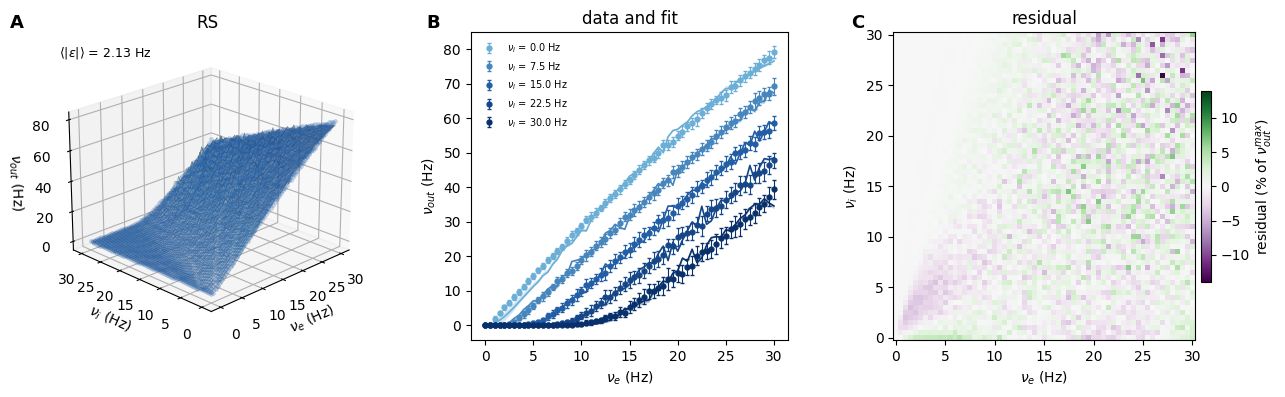

In [10]:
fig_main, axes_main = make_figure_TF_fitting(M, figsize = (15,4))

In [11]:
for ext in ('pdf', 'svg', 'png'):
    fig_main.savefig(os.path.join(fig_path, f'supp_figure_4_TF_fitting.{ext}'),
                     dpi=300, bbox_inches='tight')
print('main figure saved to', fig_path)

main figure saved to figures


## Error summary

`nRMSE_pct` is the root-mean-square residual as a percentage of that cell type's largest
simulated rate, which is what makes the three comparable. `MAE_Hz` and `RMSE_Hz` are the
same quantities in Hz.

Note that `RMSE_Hz` is unweighted and is therefore not the `mean_error` returned by
`res_2_func`, which is rate-weighted. The two should not be quoted side by side.

In [12]:
def error_summary(M):
    rows = []
    for name, m in M.items():
        resid = m['df']['residual'].to_numpy(dtype=float)
        rmse = float(np.sqrt(np.nanmean(resid ** 2)))
        rows.append({'neuron_model': name,
                     'max_rate_Hz': m['max_rate'],
                     'MAE_Hz': float(np.nanmean(np.abs(resid))),
                     'RMSE_Hz': rmse,
                     'nRMSE_pct': 100.0 * rmse / m['max_rate']})
    return pd.DataFrame(rows).set_index('neuron_model')


In [13]:
summary = error_summary(M)
summary.round(3)

,max_rate_Hz,MAE_Hz,RMSE_Hz,nRMSE_pct
neuron_model,,,,
RS,79.13,1.018,1.458,1.843


## Supplementary panels

The simulated surfaces on their own, the fitted against simulated rates, the ensemble
spread of the retained fits, and the residuals in Hz rather than as a percentage.

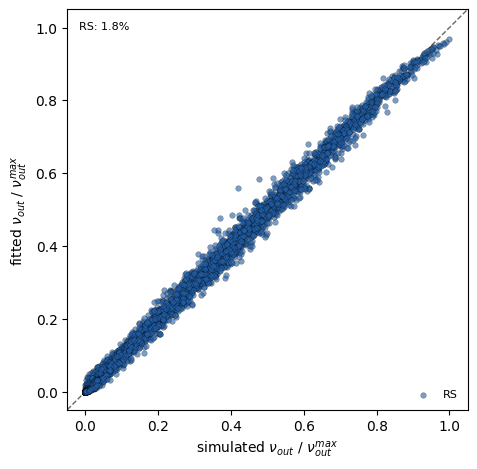

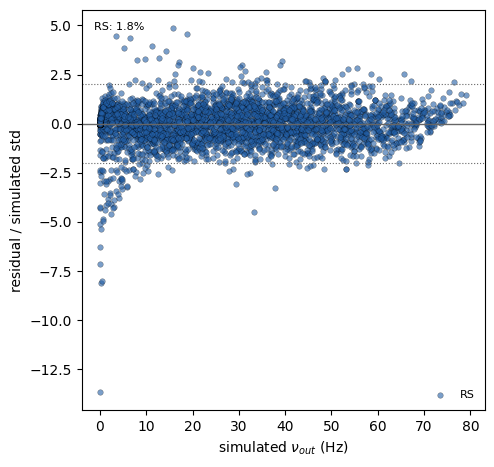

In [14]:
supp_figs=[]
# Fitted against simulated rates, all cell types on a common axis
fig_gof, _ = plot_TF_goodness_of_fit(dfs, normalise='range')
supp_figs.append(fig_gof)

# Residual in units of the simulated dispersion
fig_sigma, _ = plot_TF_goodness_of_fit(dfs, normalise='sigma')
supp_figs.append(fig_sigma)

In [15]:
save_figs(fig_path, 'TF_fitting_comparison_supplementary', supp_figs)
print(f'{len(supp_figs)} supplementary panels saved to {fig_path}')

2 supplementary panels saved to figures
